<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net" target="_blank"><img src="../images/qworld/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by Özlem Salehi Köken
        </td>        
</tr></table>

# Adiabatic Quantum Computing


Adiabatic quantum computing offers an alternative approach to gate based computation. Adiabatic quantum computing relies on quantum adiabatic theorem.

## Quantum adiabatic theorem

**Theorem:** Let time-dependent Hamiltonian $\tilde{H}(s)$ be a Hermitian operator that varies smoothly as a function of $s := t/T$ for $s \in [0,1]$. For $T$ arbitrarily large, $H(t) = \tilde{H}(t/T)$ varies arbitrarily slowly as a function of $t$. The system is initialized at $t=0$ in the state $\ket{\psi (0)}$ and evolves according to the Schrödinger equation
$$
i\frac{d}{d t} \ket{\psi(t)} = H(t)\ket{\psi(t)}.
$$

Now suppose that $\ket{\psi (0)}$ is an eigenstate of $\tilde H(0) = H(0)$, which we assume for simplicity to be the ground state. Furthermore, suppose that for all $s$, $H(s)$ has a unique ground state.

Then the adiabatic theorem says that in the limit $T \rightarrow  \infty$, the final state $\ket{\psi(T)}$ obtained by the evolution will be the ground state of $\tilde H(1) = H(T)$.

-----

In simpler terms, let $\tilde H(s)$ be a time-dependent Hamiltonian with a unique ground state for all $s$:

$$
\tilde H(s) = (1- s) H_i + sH_f \text{  for  } s \in [0,1],
$$
or equivalently
$$
H(t) = \left (1- \frac{t}{T}\right ) H_i + \frac{t}{T} H_f \text{  for  } t \in [0,T].
$$

If the system is initialized at the ground state of $H_i$ and the system evolves sufficiently slowly, the system ends up in the ground state of $H_f$.


We can see that at $t=0$, only $H_i$ acts on the system while at $t=T$, only $H_f$ acts on the system.

We are skipping the proof of this theorem. But it is worth stating that $T$ depends on the energy gap between the ground and the first
excited state, i.e., the state with the second smallest eigenvalue.

In the image below, the orange line shows how the lowest eigenvalue changes over time and the purple line indicates the eigenvalue of the first excited state.

As the two values get closer, $T$ gets larger. If the two lowest eigenvalues cross each other, then we can no longer stay in the ground state.

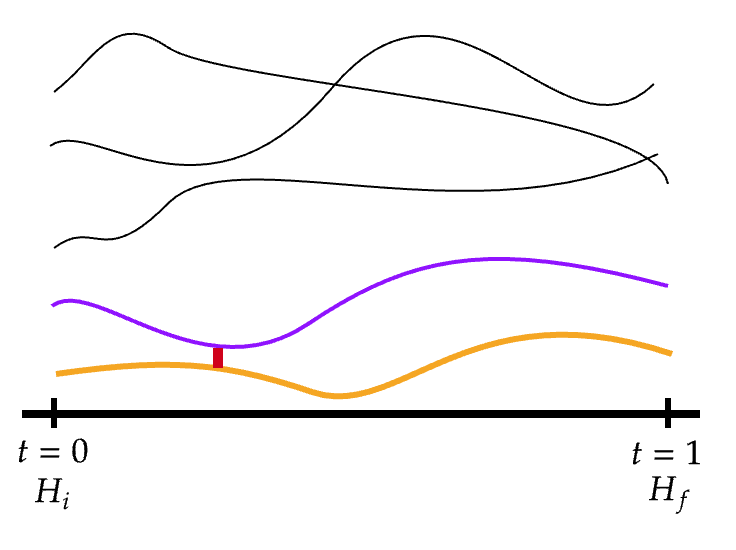


### Task 1

For $H_i = XII + IXI + IIX$ and $H_f = XZX+YZY+ZZZ$, plot the eigenvalues of the Hamiltonian  $H(t) = (1-t/T)H_i + (t/T)H_f$ for starting from $t=0$ to $t=T=50$. For each eigenvalue, use a different color.

In [ ]:
from qiskit.quantum_info import SparsePauliOp
import scipy
import matplotlib.pyplot as plt

# Define the Hamiltonians
T=50

for t in range(T):
  # Compute H_t and its eigenvalues


  for i in range(len(eigenvalues)):
    color = plt.cm.tab10(i)
    # Add the value of each eigenvalue at time t to the plot



<a href="02_adiabatic_quantum_computing_solutions.ipynb#Task1">click here for solution</a>

## Adiabatic quantum computing

Quantum adiabatic theorem provides us an alternative way for quantum computation.

Suppose that $H_f$ is a Hamiltonian, and we are interested in learning its ground state. If we initialize the system at $t=0$ with the ground state of some Hamiltonian whose ground state we already know and that is easy to prepare, the theorem states that the system is likely to end up in the ground state of $H_f$.

Although finding the lowest energy state might be NP-Hard, quantum adiabatic theorem offers a new approach for solving the problem.

It is proven that this model of computation, known as *adiabatic quantum computing*, is equivalent to the standard gate-based model of
quantum computation, though this may seem a bit counterintuitive at the beginning.


## Quantum Annealing



We will not go into details of quantum annealing in this notebook. However, it is worth mentioning here, as we discussed adiabatic quantum computing (AQC).

Quantum annealing (QA) is a heuristic optimization algorithm that runs in the framework of AQC. D-Wave company provides quantum annealers that can run quantum annealing algorithms.

Quantum annealing and AQC are often thought as the same thing. However, QA is a special case of AQC. 

- In quantum annealing, certain properties of AQC are relaxed. For instance, computation does not take place in a totally closed system. This makes quantum annealing a *heuristic* algorithm.

- AQC is universal i.e. you can simulate a gate-based quantum computer using adiabatic quantum computing, while quantum annealing is not universal.

- In QA, the Hamiltonians are stoquastic, i.e., $\bra{i}H\ket{j} \leq 0$, $\forall i,j \in \{0,1\}^n$, $i\neq j$. With this property, $H$ has real nonpositive off-diagonal matrix elements.

 Unlike simulated annealing, QA is a physical process, in which quantum fluctuations play the role of thermal fluctuations.

<figure>
    <img src='../images/qa.jpg'  width="350" />
</figure>

Currently, quantum annealing can be realized using the quantum processing units provided by **D-Wave**. Unfortunately, they are not available for access publicly. 

Next we will investigate in more detail the quantum annealing algorithm as run by D-Wave.

### Initial Hamiltonian $H_i$

The initial Hamiltonian is picked as 
$$
H_0 = \sum_{i=1}^n - \sigma_i ^x,
$$
where $\sigma_i ^x$ is the Pauli-X operator applied on qubit $i$.

Observe that

$-X|+\rangle = - |+\rangle$

$-X|-\rangle =  |+\rangle$.

Hence, $|+\rangle$ is the ground state for $-X$.

So, for the initial state we pick equal superpositon of $|0\rangle$ and $|1\rangle$ for each qubit, that is the $|+\rangle$ state. 

### Problem Hamiltonian $H_f$

In D-Wave machines, problem Hamiltonian takes the following form:
    
$$H_f = \sum_{i \in V} h_i \sigma_i^z + \sum_{(i,j)\in E} J_{ij} \sigma_i^z \sigma_j^z$$

Here $V$ is the set of qubits in D-Wave machine and $(i,j)$ are the available couplings between the qubits. You can see that only 2-local interactions are available.

$\sigma_i^z$ corresponds to the Pauli-Z operator applied on qubit $i$. 

## Energy of the system

Let us investigate the energy of the Hamiltonian $H_f$.

Pauli-Z operator is identified by the following matrix:
$$Z = \begin{pmatrix}
1&0\\
0&-1
\end{pmatrix}$$

Note that the eigenvectors of state $Z$ are $\ket{0}$ and $\ket{1}$, with eigenvalues $1$ and $-1$, respectively. Therefore for a basis state $\ket{\psi}$,
$$
Z_i\ket{\psi} = (-1)^{\psi_i}\ket{\psi} = s_i \ket{\psi},
$$
where $s_i \in \{-1,1\}$ is a spin variable. 

Hence, When $H_f$ is applied on some basis state $|\psi\rangle$, we get the following state:

\begin{align*}
H_f\ket{\psi} &= \sum_i h_i Z_i \ket{\psi}+ \sum_{i,j} J_{ij} Z_iZ_j\ket{\psi} \\
&=\left (\sum_{i } h_is_i + \sum_{i,j} J_{ij} s_i s_j \right ) \ket{\psi} \\
&= E_f  \ket{\psi}.
\end{align*}

This tells us that for diagonal Hamiltonians, which are also called Ising Hamiltonians, the computational basis states are the eigenvectors with the corresponding eigenvalue $E_f$.

$\left (\sum_{i } h_is_i + \sum_{i,j} J_{ij} s_i s_j \right )$ is called Ising Model, which we will explore in the next notebook.

# References

1. McGeoch, Catherine C. "Adiabatic quantum computation and quantum annealing: Theory and practice." Synthesis Lectures on Quantum Computing 5.2 (2014): 1-93.

2. Steven Herbert Lecture Notes, Quantum Computing, Lecture 15: Adiabatic Quantum Computing [link](https://www.cl.cam.ac.uk/teaching/1920/QuantComp/Quantum_Computing_Lecture_15.pdf)